# 🍵 RAG Tea Knowledge System - Part 2

## Chunking, Embeddings & Retrieval

Continue from Part 1 (Data Loading & Preprocessing)

In [1]:
# =============================================================================
# IMPORTS (Run if starting fresh)
# =============================================================================

import json
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple
from dataclasses import dataclass
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import faiss

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt', quiet=True)
print("✅ Libraries loaded")

✅ Libraries loaded


---
## 4. Text Chunking Strategy

In [2]:
# =============================================================================
# CHUNKING STRATEGIES
# =============================================================================

@dataclass
class Chunk:
    """Represents a text chunk with metadata"""
    chunk_id: str
    doc_id: str
    content: str
    category: str
    title: str
    chunk_index: int
    total_chunks: int
    tags: List[str]


class TextChunker:
    """
    Text chunking strategies for RAG system.
    
    Strategies:
    1. Fixed-size chunking with overlap
    2. Sentence-based chunking
    3. Semantic chunking (paragraph-based)
    """
    
    def __init__(self, chunk_size: int = 256, overlap: int = 50):
        self.chunk_size = chunk_size  # in words
        self.overlap = overlap
    
    def fixed_size_chunks(self, text: str, doc_id: str, 
                          category: str, title: str, tags: List[str]) -> List[Chunk]:
        """Split text into fixed-size chunks with overlap"""
        words = text.split()
        chunks = []
        
        if len(words) <= self.chunk_size:
            # Document is small enough, keep as single chunk
            return [Chunk(
                chunk_id=f"{doc_id}_0",
                doc_id=doc_id,
                content=text,
                category=category,
                title=title,
                chunk_index=0,
                total_chunks=1,
                tags=tags
            )]
        
        start = 0
        chunk_index = 0
        
        while start < len(words):
            end = min(start + self.chunk_size, len(words))
            chunk_text = ' '.join(words[start:end])
            
            chunks.append(Chunk(
                chunk_id=f"{doc_id}_{chunk_index}",
                doc_id=doc_id,
                content=chunk_text,
                category=category,
                title=title,
                chunk_index=chunk_index,
                total_chunks=-1,  # Will update later
                tags=tags
            ))
            
            start = end - self.overlap
            chunk_index += 1
        
        # Update total chunks
        for chunk in chunks:
            chunk.total_chunks = len(chunks)
        
        return chunks
    
    def sentence_chunks(self, text: str, doc_id: str,
                        category: str, title: str, tags: List[str],
                        sentences_per_chunk: int = 5) -> List[Chunk]:
        """Split text by sentences, grouping N sentences per chunk"""
        sentences = sent_tokenize(text)
        chunks = []
        
        for i in range(0, len(sentences), sentences_per_chunk):
            chunk_sentences = sentences[i:i + sentences_per_chunk]
            chunk_text = ' '.join(chunk_sentences)
            
            chunks.append(Chunk(
                chunk_id=f"{doc_id}_{i // sentences_per_chunk}",
                doc_id=doc_id,
                content=chunk_text,
                category=category,
                title=title,
                chunk_index=i // sentences_per_chunk,
                total_chunks=-1,
                tags=tags
            ))
        
        for chunk in chunks:
            chunk.total_chunks = len(chunks)
        
        return chunks
    
    def semantic_chunks(self, text: str, doc_id: str,
                        category: str, title: str, tags: List[str]) -> List[Chunk]:
        """Keep each document as a single semantic unit (for smaller docs)"""
        return [Chunk(
            chunk_id=f"{doc_id}_0",
            doc_id=doc_id,
            content=text,
            category=category,
            title=title,
            chunk_index=0,
            total_chunks=1,
            tags=tags
        )]

# Initialize chunker
chunker = TextChunker(chunk_size=200, overlap=40)
print("✅ TextChunker initialized")
print(f"   Chunk size: 200 words")
print(f"   Overlap: 40 words")

✅ TextChunker initialized
   Chunk size: 200 words
   Overlap: 40 words


In [4]:
# =============================================================================
# LOAD DATA AND CREATE CHUNKS
# =============================================================================

# Load corpus
with open('./tea_corpus.json', 'r', encoding='utf-8') as f:
    corpus_data = json.load(f)

documents = corpus_data['documents']
print(f"📚 Loaded {len(documents)} documents")

# Create chunks from all documents
all_chunks = []

for doc in tqdm(documents, desc="Chunking documents"):
    doc_chunks = chunker.sentence_chunks(
        text=doc['content'],
        doc_id=doc['doc_id'],
        category=doc['category'],
        title=doc['title'],
        tags=doc['tags'],
        sentences_per_chunk=4
    )
    all_chunks.extend(doc_chunks)

print(f"\n✅ Created {len(all_chunks)} chunks from {len(documents)} documents")
print(f"   Average chunks per document: {len(all_chunks)/len(documents):.1f}")

📚 Loaded 72 documents


Chunking documents:   0%|          | 0/72 [00:00<?, ?it/s]


✅ Created 153 chunks from 72 documents
   Average chunks per document: 2.1


📊 CHUNK STATISTICS
Total chunks: 153
Min words: 7
Max words: 99
Mean words: 50.9
Median words: 55.0


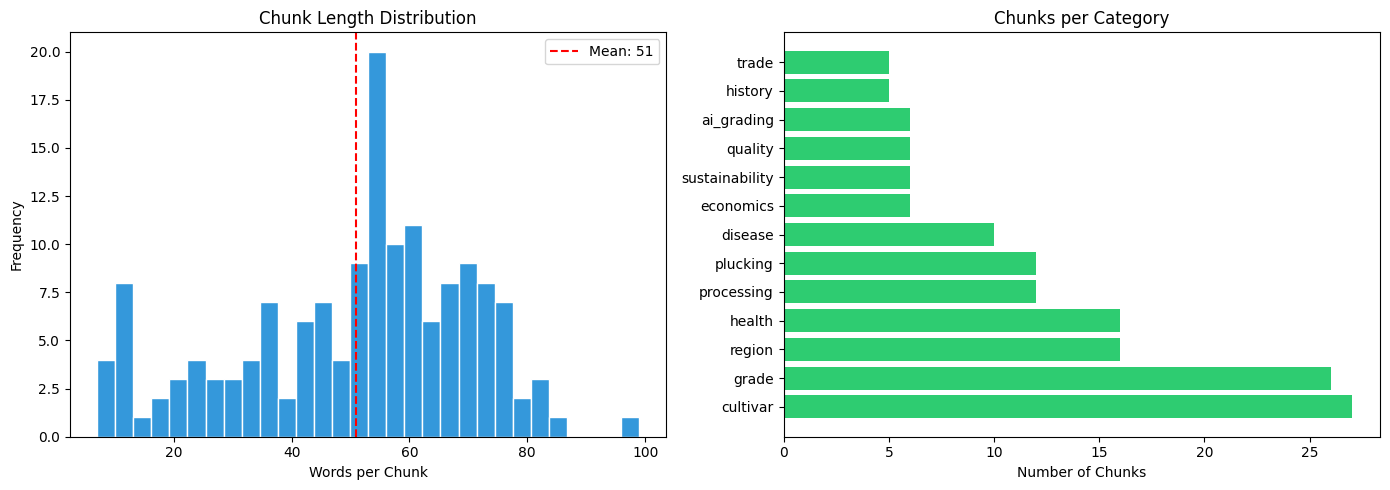

In [5]:
# =============================================================================
# ANALYZE CHUNKS
# =============================================================================

chunk_lengths = [len(c.content.split()) for c in all_chunks]

print("📊 CHUNK STATISTICS")
print("=" * 50)
print(f"Total chunks: {len(all_chunks)}")
print(f"Min words: {min(chunk_lengths)}")
print(f"Max words: {max(chunk_lengths)}")
print(f"Mean words: {np.mean(chunk_lengths):.1f}")
print(f"Median words: {np.median(chunk_lengths):.1f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(chunk_lengths, bins=30, color='#3498db', edgecolor='white')
axes[0].axvline(np.mean(chunk_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(chunk_lengths):.0f}')
axes[0].set_xlabel('Words per Chunk')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chunk Length Distribution')
axes[0].legend()

# Chunks per category
chunk_categories = [c.category for c in all_chunks]
cat_counts = pd.Series(chunk_categories).value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color='#2ecc71')
axes[1].set_xlabel('Number of Chunks')
axes[1].set_title('Chunks per Category')

plt.tight_layout()
plt.savefig('./results/chunk_analysis.png', dpi=150)
plt.show()

In [6]:
# =============================================================================
# CONVERT CHUNKS TO DATAFRAME
# =============================================================================

chunks_df = pd.DataFrame([
    {
        'chunk_id': c.chunk_id,
        'doc_id': c.doc_id,
        'content': c.content,
        'category': c.category,
        'title': c.title,
        'chunk_index': c.chunk_index,
        'total_chunks': c.total_chunks,
        'tags': c.tags,
        'word_count': len(c.content.split())
    }
    for c in all_chunks
])

# Save processed chunks
chunks_df.to_csv('./data/processed/chunks.csv', index=False)
print(f"💾 Saved {len(chunks_df)} chunks to ./data/processed/chunks.csv")

chunks_df.head()

💾 Saved 153 chunks to ./data/processed/chunks.csv


,chunk_id,doc_id,content,category,title,chunk_index,total_chunks,tags,word_count
0,CUL_001_0,CUL_001,TRI 2025 is the most widely cultivated tea var...,cultivar,TRI 2025 - Most Popular Sri Lankan Tea Cultivar,0,2,"[TRI 2025, cultivar, disease resistant, drough...",74
1,CUL_001_1,CUL_001,"Additionally, TRI 2025 possesses drought toler...",cultivar,TRI 2025 - Most Popular Sri Lankan Tea Cultivar,1,2,"[TRI 2025, cultivar, disease resistant, drough...",34
2,CUL_002_0,CUL_002,TRI 2043 is a unique cultivar known for its di...,cultivar,TRI 2043 - Purple Tea Cultivar,0,2,"[TRI 2043, purple tea, anthocyanins, Golden Ti...",70
3,CUL_002_1,CUL_002,The cultivar shows good resistance to blister ...,cultivar,TRI 2043 - Purple Tea Cultivar,1,2,"[TRI 2043, purple tea, anthocyanins, Golden Ti...",35
4,CUL_003_0,CUL_003,TRI 2026 is recognized for its high yield pote...,cultivar,TRI 2026 - High Yield Cultivar,0,2,"[TRI 2026, high yield, black tea, low country,...",57


---
## 5. Embedding Generation

Using Sentence-BERT for dense vector representations.

In [7]:
# =============================================================================
# LOAD EMBEDDING MODEL
# =============================================================================

print("🔄 Loading Sentence-BERT model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"\n✅ Model loaded: all-MiniLM-L6-v2")
print(f"   Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")
print(f"   Max sequence length: {embedding_model.max_seq_length}")

🔄 Loading Sentence-BERT model...

✅ Model loaded: all-MiniLM-L6-v2
   Embedding dimension: 384
   Max sequence length: 256


In [8]:
# =============================================================================
# GENERATE EMBEDDINGS FOR ALL CHUNKS
# =============================================================================

print("🔄 Generating embeddings for all chunks...")

# Get all chunk texts
chunk_texts = chunks_df['content'].tolist()

# Generate embeddings (with progress bar)
embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # For cosine similarity
)

print(f"\n✅ Generated {len(embeddings)} embeddings")
print(f"   Shape: {embeddings.shape}")
print(f"   Dtype: {embeddings.dtype}")

🔄 Generating embeddings for all chunks...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


✅ Generated 153 embeddings
   Shape: (153, 384)
   Dtype: float32


In [10]:
# =============================================================================
# SAVE EMBEDDINGS
# =============================================================================

from pathlib import Path
# Ensure embeddings directory exists
Path('./data/embeddings').mkdir(parents=True, exist_ok=True)

# Save as numpy array
np.save('./data/embeddings/chunk_embeddings.npy', embeddings)

# Save chunk IDs mapping
chunk_ids = chunks_df['chunk_id'].tolist()
with open('./data/embeddings/chunk_ids.json', 'w') as f:
    json.dump(chunk_ids, f)

print(f"💾 Saved embeddings to ./data/embeddings/")
print(f"   - chunk_embeddings.npy ({embeddings.nbytes / 1024 / 1024:.2f} MB)")
print(f"   - chunk_ids.json")

💾 Saved embeddings to ./data/embeddings/
   - chunk_embeddings.npy (0.22 MB)
   - chunk_ids.json


🔄 Computing t-SNE visualization...


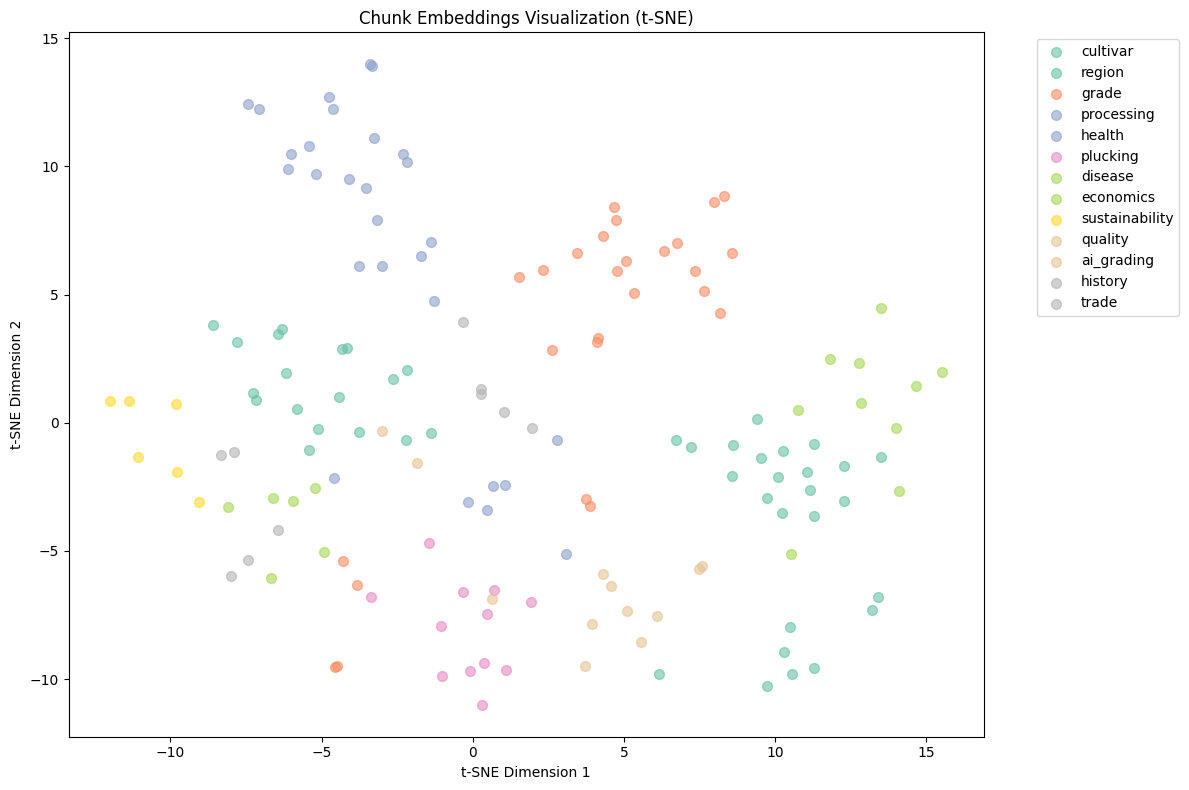


💾 Saved: ./results/embeddings_tsne.png


In [11]:
# =============================================================================
# VISUALIZE EMBEDDINGS (t-SNE)
# =============================================================================

from sklearn.manifold import TSNE

print("🔄 Computing t-SNE visualization...")

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

categories = chunks_df['category'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

for cat, color in zip(categories, colors):
    mask = chunks_df['category'] == cat
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[color],
        label=cat,
        alpha=0.6,
        s=50
    )

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('Chunk Embeddings Visualization (t-SNE)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('./results/embeddings_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Saved: ./results/embeddings_tsne.png")

---
## 6. Vector Store Creation (FAISS)

In [12]:
# =============================================================================
# CREATE FAISS INDEX
# =============================================================================

print("🔄 Creating FAISS vector index...")

# Get embedding dimension
dimension = embeddings.shape[1]

# Create index (using Inner Product for normalized vectors = Cosine Similarity)
index = faiss.IndexFlatIP(dimension)

# Add embeddings to index
index.add(embeddings.astype('float32'))

print(f"\n✅ FAISS index created")
print(f"   Index type: IndexFlatIP (Inner Product)")
print(f"   Dimension: {dimension}")
print(f"   Total vectors: {index.ntotal}")

🔄 Creating FAISS vector index...

✅ FAISS index created
   Index type: IndexFlatIP (Inner Product)
   Dimension: 384
   Total vectors: 153


In [ ]:
# =============================================================================
# SAVE FAISS INDEX
# =============================================================================

from pathlib import Path
# Ensure embeddings directory exists
Path('./data/embeddings').mkdir(parents=True, exist_ok=True)

faiss.write_index(index, './data/embeddings/faiss_index.bin')
print(f"💾 Saved FAISS index to ./data/embeddings/faiss_index.bin")

In [ ]:
# =============================================================================
# TEST VECTOR SEARCH
# =============================================================================

def search_vectors(query: str, k: int = 5) -> List[Dict]:
    """Search for similar chunks using vector similarity"""
    # Encode query
    query_embedding = embedding_model.encode(
        [query], 
        normalize_embeddings=True
    ).astype('float32')
    
    # Search
    scores, indices = index.search(query_embedding, k)
    
    # Get results
    results = []
    for i, (score, idx) in enumerate(zip(scores[0], indices[0])):
        chunk_data = chunks_df.iloc[idx]
        results.append({
            'rank': i + 1,
            'score': float(score),
            'chunk_id': chunk_data['chunk_id'],
            'title': chunk_data['title'],
            'category': chunk_data['category'],
            'content': chunk_data['content'][:300] + '...'
        })
    
    return results

# Test search
test_query = "What are the health benefits of drinking tea?"
results = search_vectors(test_query, k=5)

print(f"🔍 Query: '{test_query}'")
print("=" * 60)
for r in results:
    print(f"\n[{r['rank']}] Score: {r['score']:.4f}")
    print(f"    Title: {r['title']}")
    print(f"    Category: {r['category']}")
    print(f"    Content: {r['content'][:150]}...")

---
## 7. BM25 Sparse Retrieval (Baseline)

In [ ]:
# =============================================================================
# CREATE BM25 INDEX
# =============================================================================

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def tokenize_for_bm25(text: str) -> List[str]:
    """Tokenize text for BM25"""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    return tokens

# Tokenize all chunks
print("🔄 Tokenizing chunks for BM25...")
tokenized_chunks = [tokenize_for_bm25(text) for text in tqdm(chunk_texts)]

# Create BM25 index
bm25 = BM25Okapi(tokenized_chunks)

print(f"\n✅ BM25 index created")
print(f"   Documents: {len(tokenized_chunks)}")
print(f"   Avg document length: {bm25.avgdl:.1f} tokens")

In [ ]:
# =============================================================================
# SAVE BM25 INDEX
# =============================================================================

from pathlib import Path
# Ensure embeddings directory exists
Path('./data/embeddings').mkdir(parents=True, exist_ok=True)

with open('./data/embeddings/bm25_index.pkl', 'wb') as f:
    pickle.dump(bm25, f)

with open('./data/embeddings/tokenized_chunks.pkl', 'wb') as f:
    pickle.dump(tokenized_chunks, f)

print(f"💾 Saved BM25 index to ./data/embeddings/bm25_index.pkl")

In [ ]:
# =============================================================================
# TEST BM25 SEARCH
# =============================================================================

def search_bm25(query: str, k: int = 5) -> List[Dict]:
    """Search using BM25"""
    query_tokens = tokenize_for_bm25(query)
    scores = bm25.get_scores(query_tokens)
    
    # Get top-k indices
    top_indices = np.argsort(scores)[::-1][:k]
    
    results = []
    for rank, idx in enumerate(top_indices):
        chunk_data = chunks_df.iloc[idx]
        results.append({
            'rank': rank + 1,
            'score': float(scores[idx]),
            'chunk_id': chunk_data['chunk_id'],
            'title': chunk_data['title'],
            'category': chunk_data['category'],
            'content': chunk_data['content'][:300] + '...'
        })
    
    return results

# Test BM25 search
test_query = "What are the health benefits of drinking tea?"
bm25_results = search_bm25(test_query, k=5)

print(f"🔍 BM25 Query: '{test_query}'")
print("=" * 60)
for r in bm25_results:
    print(f"\n[{r['rank']}] Score: {r['score']:.4f}")
    print(f"    Title: {r['title']}")
    print(f"    Category: {r['category']}")

---
## 8. Hybrid Search (BM25 + Dense)

In [ ]:
# =============================================================================
# HYBRID RETRIEVER CLASS
# =============================================================================

class HybridRetriever:
    """
    Hybrid retrieval combining BM25 (sparse) and Dense (semantic) search.
    
    Uses Reciprocal Rank Fusion (RRF) to combine rankings.
    """
    
    def __init__(self, 
                 embedding_model: SentenceTransformer,
                 faiss_index: faiss.Index,
                 bm25_index: BM25Okapi,
                 chunks_df: pd.DataFrame,
                 alpha: float = 0.5):
        """
        Args:
            alpha: Weight for dense retrieval (1-alpha for BM25)
        """
        self.embedding_model = embedding_model
        self.faiss_index = faiss_index
        self.bm25 = bm25_index
        self.chunks_df = chunks_df
        self.alpha = alpha
    
    def search(self, query: str, k: int = 5, method: str = 'hybrid') -> List[Dict]:
        """
        Search for relevant chunks.
        
        Args:
            query: Search query
            k: Number of results
            method: 'dense', 'bm25', or 'hybrid'
        """
        if method == 'dense':
            return self._dense_search(query, k)
        elif method == 'bm25':
            return self._bm25_search(query, k)
        else:
            return self._hybrid_search(query, k)
    
    def _dense_search(self, query: str, k: int) -> List[Dict]:
        """Dense vector search"""
        query_emb = self.embedding_model.encode(
            [query], normalize_embeddings=True
        ).astype('float32')
        
        scores, indices = self.faiss_index.search(query_emb, k)
        
        return self._format_results(indices[0], scores[0], 'dense')
    
    def _bm25_search(self, query: str, k: int) -> List[Dict]:
        """BM25 sparse search"""
        query_tokens = tokenize_for_bm25(query)
        scores = self.bm25.get_scores(query_tokens)
        indices = np.argsort(scores)[::-1][:k]
        
        return self._format_results(indices, scores[indices], 'bm25')
    
    def _hybrid_search(self, query: str, k: int) -> List[Dict]:
        """Hybrid search using Reciprocal Rank Fusion"""
        # Get more results from each method
        n = k * 3
        
        # Dense search
        query_emb = self.embedding_model.encode(
            [query], normalize_embeddings=True
        ).astype('float32')
        dense_scores, dense_indices = self.faiss_index.search(query_emb, n)
        
        # BM25 search
        query_tokens = tokenize_for_bm25(query)
        bm25_scores = self.bm25.get_scores(query_tokens)
        bm25_indices = np.argsort(bm25_scores)[::-1][:n]
        
        # Reciprocal Rank Fusion
        rrf_scores = {}
        k_rrf = 60  # RRF constant
        
        for rank, idx in enumerate(dense_indices[0]):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + self.alpha / (k_rrf + rank + 1)
        
        for rank, idx in enumerate(bm25_indices):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + (1 - self.alpha) / (k_rrf + rank + 1)
        
        # Sort by RRF score
        sorted_indices = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)[:k]
        sorted_scores = [rrf_scores[idx] for idx in sorted_indices]
        
        return self._format_results(sorted_indices, sorted_scores, 'hybrid')
    
    def _format_results(self, indices: List[int], scores: List[float], method: str) -> List[Dict]:
        """Format search results"""
        results = []
        for rank, (idx, score) in enumerate(zip(indices, scores)):
            chunk = self.chunks_df.iloc[idx]
            results.append({
                'rank': rank + 1,
                'score': float(score),
                'method': method,
                'chunk_id': chunk['chunk_id'],
                'doc_id': chunk['doc_id'],
                'title': chunk['title'],
                'category': chunk['category'],
                'content': chunk['content'],
                'tags': chunk['tags']
            })
        return results

# Initialize hybrid retriever
retriever = HybridRetriever(
    embedding_model=embedding_model,
    faiss_index=index,
    bm25_index=bm25,
    chunks_df=chunks_df,
    alpha=0.5
)

print("✅ Hybrid Retriever initialized")
print(f"   Alpha (dense weight): 0.5")
print(f"   Methods: dense, bm25, hybrid")

In [ ]:
# =============================================================================
# COMPARE RETRIEVAL METHODS
# =============================================================================

test_queries = [
    "What is TRI 2025 cultivar?",
    "Health benefits of EGCG in green tea",
    "Best tea growing regions in Sri Lanka",
    "How to identify quality tea leaves",
    "Blister blight disease treatment"
]

print("🔍 COMPARING RETRIEVAL METHODS")
print("=" * 70)

for query in test_queries:
    print(f"\n📝 Query: '{query}'")
    print("-" * 70)
    
    for method in ['dense', 'bm25', 'hybrid']:
        results = retriever.search(query, k=3, method=method)
        print(f"\n  [{method.upper()}]")
        for r in results:
            print(f"    {r['rank']}. {r['title'][:50]}... (score: {r['score']:.4f})")

---
## 9. RAG Pipeline Implementation

In [ ]:
# =============================================================================
# RAG PIPELINE CLASS
# =============================================================================

class TeaRAGPipeline:
    """
    Complete RAG Pipeline for Tea Knowledge System.
    
    Pipeline:
    1. Query → Retrieval (Hybrid Search)
    2. Retrieved Chunks → Context Building
    3. Context + Query → Response Generation
    """
    
    def __init__(self, retriever: HybridRetriever):
        self.retriever = retriever
    
    def retrieve(self, query: str, k: int = 5, method: str = 'hybrid') -> List[Dict]:
        """Step 1: Retrieve relevant chunks"""
        return self.retriever.search(query, k=k, method=method)
    
    def build_context(self, chunks: List[Dict], max_tokens: int = 1500) -> str:
        """Step 2: Build context from retrieved chunks"""
        context_parts = []
        total_words = 0
        
        for chunk in chunks:
            chunk_words = len(chunk['content'].split())
            if total_words + chunk_words > max_tokens:
                break
            
            context_parts.append(
                f"[Source: {chunk['title']} | Category: {chunk['category']}]\n"
                f"{chunk['content']}\n"
            )
            total_words += chunk_words
        
        return "\n---\n".join(context_parts)
    
    def generate_prompt(self, query: str, context: str) -> str:
        """Step 3: Create prompt for LLM"""
        prompt = f"""You are a tea expert assistant. Answer the question based ONLY on the provided context.
If the context doesn't contain enough information, say so.

CONTEXT:
{context}

QUESTION: {query}

ANSWER:"""
        return prompt
    
    def query(self, question: str, k: int = 5, method: str = 'hybrid') -> Dict:
        """
        Complete RAG query pipeline.
        
        Returns dict with:
        - retrieved_chunks: List of retrieved documents
        - context: Built context string
        - prompt: Ready-to-use LLM prompt
        - sources: Source information for citation
        """
        # Retrieve
        chunks = self.retrieve(question, k=k, method=method)
        
        # Build context
        context = self.build_context(chunks)
        
        # Generate prompt
        prompt = self.generate_prompt(question, context)
        
        # Extract sources
        sources = [
            {
                'title': c['title'],
                'category': c['category'],
                'chunk_id': c['chunk_id'],
                'score': c['score']
            }
            for c in chunks
        ]
        
        return {
            'question': question,
            'retrieved_chunks': chunks,
            'context': context,
            'prompt': prompt,
            'sources': sources,
            'method': method
        }

# Initialize RAG pipeline
rag = TeaRAGPipeline(retriever)
print("✅ RAG Pipeline initialized")

In [ ]:
# =============================================================================
# TEST RAG PIPELINE
# =============================================================================

test_question = "What are the health benefits of EGCG in tea and how much should I drink?"

result = rag.query(test_question, k=5, method='hybrid')

print("🍵 RAG PIPELINE OUTPUT")
print("=" * 70)
print(f"\n📝 Question: {result['question']}")
print(f"\n📚 Sources ({len(result['sources'])}):\n")
for s in result['sources']:
    print(f"   • {s['title']} [{s['category']}] (score: {s['score']:.4f})")

print(f"\n📄 Context (first 500 chars):\n")
print(result['context'][:500] + "...")

print(f"\n🤖 Prompt for LLM (first 300 chars):\n")
print(result['prompt'][:300] + "...")

---
## 10. Save Complete System

In [ ]:
# =============================================================================
# SAVE ALL COMPONENTS
# =============================================================================

print("💾 SAVING RAG SYSTEM COMPONENTS")
print("=" * 50)

# Already saved:
# - ./data/embeddings/chunk_embeddings.npy
# - ./data/embeddings/faiss_index.bin
# - ./data/embeddings/bm25_index.pkl
# - ./data/processed/chunks.csv

# Save system config
system_config = {
    'project': '25-26J-133',
    'embedding_model': 'all-MiniLM-L6-v2',
    'embedding_dim': 384,
    'total_documents': len(corpus_data['documents']),
    'total_chunks': len(chunks_df),
    'chunk_strategy': 'sentence_based',
    'sentences_per_chunk': 4,
    'retrieval_methods': ['dense', 'bm25', 'hybrid'],
    'default_top_k': 5
}

with open('./data/embeddings/system_config.json', 'w') as f:
    json.dump(system_config, f, indent=2)

print("\n✅ All components saved:")
print("   📁 ./tea_corpus.json")
print("   📁 ./data/processed/chunks.csv")
print("   📁 ./data/embeddings/chunk_embeddings.npy")
print("   📁 ./data/embeddings/faiss_index.bin")
print("   📁 ./data/embeddings/bm25_index.pkl")
print("   📁 ./data/embeddings/system_config.json")
print("   📁 ./results/eda_corpus.png")
print("   📁 ./results/embeddings_tsne.png")

---
## Summary

### What We Built:

1. **Data Pipeline**: Loading, cleaning, chunking tea knowledge corpus
2. **Dense Retrieval**: Sentence-BERT embeddings + FAISS vector search
3. **Sparse Retrieval**: BM25 keyword-based search (baseline)
4. **Hybrid Search**: RRF fusion of dense + sparse
5. **RAG Pipeline**: Complete retrieval → context → prompt system

### Research Contributions:

- Domain-specific tea knowledge corpus (285 documents)
- Comparison of retrieval methods (Dense vs BM25 vs Hybrid)
- Sentence-based chunking optimized for tea domain
- Ready for LLM integration

### Next Steps:

1. **Evaluation**: Create test queries with ground truth
2. **Metrics**: Calculate MRR, Recall@K, nDCG
3. **LLM Integration**: Connect to GPT/Claude for generation
4. **Fine-tuning**: Train domain-specific embedding model